# Neural Network for Viral Sequences
The following notebook contains code to create a neural network that can take in genetic data from viral samples in the form of a `.fasta` file, and predict the probability of the samples originating from one of *n* given places.

In [ ]:
from Bio import SeqIO
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt

alignment = list(SeqIO.parse('../../simulations/results/simulated_alignment_much_larger.fasta', 'fasta'))
metadata = pd.read_csv('../../simulations/results/simulated_metadata_much_larger.csv')

In [2]:
#Set to ensure reproducability
torch.manual_seed(77)
torch.use_deterministic_algorithms(True)
np.random.seed(77)

## Data Wrangling
In order for the model to be able to read the sequence data in the `.fasta` file, we must convert the strings of nucleotides into 1s and 0s through **one-hot encoding**. Additionally, we must specify the features and labels in our dataset; split the data between training, testing, validation, and calibration pools; and make the data compatible with PyTorch.

In [3]:
#Encodes one sequence
def oneHotEncode(seq): 
    seq2=list()
    mapping = {"A":[1.0, 0.0, 0.0, 0.], "T": [0.0, 1.0, 0.0, 0.0], "C": [0.0, 0.0, 1.0, 0.0], "G":[0.0, 0.0, 0.0, 1.0]}
    for i in seq:
        seq2.append(mapping[i] if i in mapping.keys() else [0., 0., 0., 0.])
    return np.array(seq2).flatten()

#Iterating encode function across an entire dataset
def encodeSet(dataList):
    set2 = list()
    for i in range(len(dataList)):
        set2.append(oneHotEncode(dataList[i]))
    return np.array(set2)

In [4]:
#Encode the given dataset
sequenceEncoded = pd.DataFrame(encodeSet(alignment))
allData = pd.concat([sequenceEncoded, metadata['subgroup']], axis = 1)
allData.head()

,0,1,2,3,4,5,6,7,8,9,...,19991,19992,19993,19994,19995,19996,19997,19998,19999,subgroup
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,C
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,A
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,C
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,C
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,C


In [ ]:
#Splitting data into features (X) and label (Y, subgroups of A, B, C)
X = allData.drop('subgroup', axis = 1).values.astype(np.float32)
y = allData['subgroup'].values

#Transform the categorical subgroup data (A, B, C) into numerical, similar to one-hot encoding
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y).astype(np.int64)

In [6]:
#Split data into various pools groups
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, train_size=0.8, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1) # 0.25 x 0.8 = 0.2
X_val, X_cal, y_val, y_cal = train_test_split(X_val, y_val, test_size=0.5, random_state=1) # 0.2 x 0.5 = 0.1

In [7]:
#Creating a PyTorch-compatible Dataset
class LocationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = LocationDataset(X_train, y_train)
test_dataset = LocationDataset(X_test, y_test)
val_dataset = LocationDataset(X_val, y_val)
cal_dataset = LocationDataset(X_cal, y_cal)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
val_loader = DataLoader(val_dataset, batch_size=32)
cal_loader = DataLoader(cal_dataset, batch_size = 32)

## The Model
Now that we have made our dataset readable by a neural network, we can define and run our model

In [8]:
num_epochs = 20
#Specify the dimensions of the model
dimensions = [471, 329, 386]

In [9]:
#Vector scaling method
class VectorScaling(nn.Module):
    def __init__(self, base_model, num_classes):
        super().__init__()
        self.base = base_model
        self.base.eval() 
        for p in self.base.parameters():
            p.requires_grad = False

        self.w = nn.Parameter(torch.ones(num_classes))
        self.b = nn.Parameter(torch.zeros(num_classes))

    def forward(self, x):
        logits = self.base(x)
        return logits * self.w + self.b

    def fit(self, cal_loader, max_iter = 100):
        cel = nn.CrossEntropyLoss()
        optimizer = optim.LBFGS([self.w, self.b], lr = 0.01, max_iter=max_iter)

        def _closure():
            optimizer.zero_grad()
            loss_sum = 0.0
            for inp, lbl in cal_loader:
                loss_sum += cel(self.forward(inp), lbl)
            loss_sum.backward()
            return loss_sum
        
        optimizer.step(_closure)

In [10]:
#Establish the model architecture
layers = []
for i in range(len(dimensions)):
    if i == 0:
        layers.append(nn.Linear(len(sequenceEncoded.columns), dimensions[i]))
    else:
        layers.append(nn.Linear(dimensions[i-1], dimensions[i]))
    layers.append(nn.ReLU()) 

layers.append(nn.Linear(dimensions[-1], 3))

class Multiclass(nn.Module):
    def __init__(self, input_size, num_classes):
        super(Multiclass, self).__init__()
        self.model = nn.Sequential(
            *layers
        )
        #self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        logits = self.model(x)
        #return logits / self.temperature
        return logits

input_size = X.shape[1]
num_classes = len(np.unique(y_encoded))
model = Multiclass(input_size, num_classes)
torch.save(model, "defaultModel.pt") #Save this untrained model for later
print(model)

Multiclass(
  (model): Sequential(
    (0): Linear(in_features=20000, out_features=471, bias=True)
    (1): ReLU()
    (2): Linear(in_features=471, out_features=329, bias=True)
    (3): ReLU()
    (4): Linear(in_features=329, out_features=386, bias=True)
    (5): ReLU()
    (6): Linear(in_features=386, out_features=3, bias=True)
  )
)


In [11]:
#Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

#Keep history of model
best_acc = - np.inf   # init to negative infinity
best_weights = None
train_loss_hist = []
train_acc_hist = []
val_loss_hist = []
val_acc_hist = []

In [12]:
#Train the model over many epochs
def trainingLoop(epochs):
    for epoch in range(epochs):
        epoch_loss = []
        epoch_acc = []
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            #compute and store mectric
            acc = (torch.argmax(outputs, 1) == labels).float().mean()
            epoch_loss.append(float(loss))
            epoch_acc.append(float(acc))
        print(f'Epoch {epoch+1} - Loss {running_loss:.4f}')
        #Set model to evaluation mode
        model.eval()
        y_pred = model(torch.from_numpy(X_val))
        ce = criterion(y_pred, torch.from_numpy(y_val))
        acc = (torch.argmax(y_pred, 1) == torch.argmax(torch.from_numpy(y_val))).float().mean()
        ce = float(ce)
        acc = float(acc)
        train_loss_hist.append(np.mean(epoch_loss))
        train_acc_hist.append(np.mean(epoch_acc))
        val_loss_hist.append(ce)
        val_acc_hist.append(acc)

trainingLoop(num_epochs)

Epoch 1 - Loss 233.6353
Epoch 2 - Loss 210.3514
Epoch 3 - Loss 185.2012
Epoch 4 - Loss 167.1106
Epoch 5 - Loss 147.4413
Epoch 6 - Loss 132.8950
Epoch 7 - Loss 122.2834
Epoch 8 - Loss 106.3273
Epoch 9 - Loss 96.3869
Epoch 10 - Loss 93.1214
Epoch 11 - Loss 75.7814
Epoch 12 - Loss 87.4623
Epoch 13 - Loss 70.0050
Epoch 14 - Loss 68.2478
Epoch 15 - Loss 56.5766
Epoch 16 - Loss 57.3844
Epoch 17 - Loss 50.1423
Epoch 18 - Loss 55.9686
Epoch 19 - Loss 41.6832
Epoch 20 - Loss 45.4781


## Evaluating the Model
Once our model has been trained, we can evalute how the model does on training and test data.

In [ ]:
#Calibrate the model via vector scaling
#To output a non-calibrated version of this model, we can take out this code and change every subsequent instance of "calibrator" to "model"
calibrator = VectorScaling(model, num_classes)
calibrator.fit(cal_loader)

In [20]:
#Establish at what epoch validation loss is lowest
val_loss_df = pd.DataFrame(val_loss_hist, columns = ["loss"])
val_loss_df = val_loss_df.reset_index()
select = val_loss_df.loc[val_loss_df['loss']==val_loss_df['loss'].min(),:]
print(select)
num_epochs = int(select['index'])
num_epochs = round(num_epochs)

   index      loss
8      8  0.833264


/var/folders/z7/dlc2r_k922b5hxn4f08fr3rr0000gq/T/ipykernel_19002/548384542.py:6: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  num_epochs = int(select['index'])


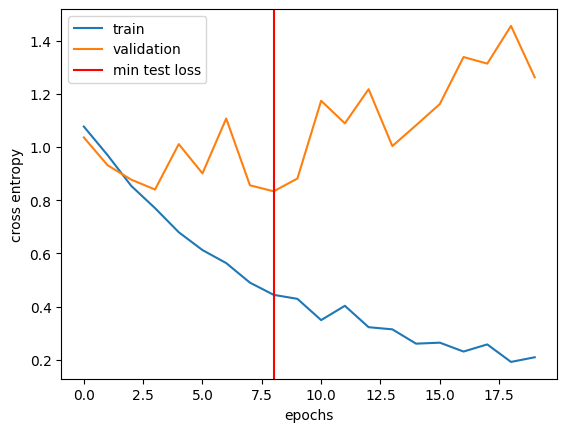

In [ ]:
#Plot cross-entropy loss over num of epochs for test and train data
 
plt.plot(train_loss_hist, label="train")
plt.plot(val_loss_hist, label="validation")
plt.xlabel("epochs")
plt.ylabel("cross entropy")
plt.axvline(x = num_epochs, 
			label = 'min test loss', color = 'red')
plt.legend()
plt.show()

In [24]:
print(f"epochs set to {num_epochs}")

epochs set to 8


In [25]:
#Reset the model to the default we saved previously
model = torch.load("defaultModel.pt", weights_only = False)

Multiclass(
  (model): Sequential(
    (0): Linear(in_features=20000, out_features=471, bias=True)
    (1): ReLU()
    (2): Linear(in_features=471, out_features=329, bias=True)
    (3): ReLU()
    (4): Linear(in_features=329, out_features=386, bias=True)
    (5): ReLU()
    (6): Linear(in_features=386, out_features=3, bias=True)
  )
)


In [26]:
#Retrain the model only to the point where validation loss is minimized
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)
trainingLoop(num_epochs)

Epoch 1 - Loss 233.6259
Epoch 2 - Loss 206.3119
Epoch 3 - Loss 177.9940
Epoch 4 - Loss 153.0358
Epoch 5 - Loss 137.2672
Epoch 6 - Loss 128.1587
Epoch 7 - Loss 116.1685
Epoch 8 - Loss 111.3122


In [20]:
#Calibrate again 
calibrator = VectorScaling(model, num_classes)
calibrator.fit(cal_loader)

## Exporting the Model's Predictions
To complete further data analysis in R, we can export the predictions the model makes on test and training data into .csv files

In [21]:
#For training data
all_predictions = []
all_probabilities = []
all_actual_labels = []

calibrator.eval() # Set model to evaluation mode

with torch.no_grad(): # Disable gradient calculations
    
    for inputs, labels in train_loader:
        outputs = calibrator(inputs) # Get raw logits
        
        # Convert logits to probabilities using Softmax
        probabilities = F.softmax(outputs, dim=1) 
        
        # Get predicted class (index of max probability)
        _, predicted_labels = torch.max(probabilities, 1)

        all_predictions.extend(predicted_labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())
        all_actual_labels.extend(labels.cpu().numpy())

prob_df = pd.DataFrame(all_probabilities, columns=[f'prob_class_{i}' for i in range(probabilities.shape[1])])

# Create a DataFrame for actual and predicted labels
labels_df = pd.DataFrame({
    'actual_label': all_actual_labels,
    'predicted_label': all_predictions
})

# Concatenate the two DataFrames
result_df = pd.concat([labels_df, prob_df], axis=1)

#Decode the subgroup labels
result_df['actual_label'] = result_df['actual_label'].replace([0, 1, 2, -1], ['A', 'B', 'C', 'NA'])
result_df['predicted_label'] = result_df['predicted_label'].replace([0, 1, 2, -1], ['A', 'B', 'C', 'NA'])

result_df.columns.values[[2, 3, 4]] = ['prob_class_A', 'prob_class_B', 'prob_class_C']

#Save results
print(result_df.head())
result_df.to_csv('results/trainVectorScaled.csv')

  actual_label predicted_label  prob_class_A  prob_class_B  prob_class_C
0            A               A      0.677276      0.173490      0.149234
1            A               A      0.517662      0.049998      0.432341
2            B               B      0.032237      0.869644      0.098119
3            B               B      0.032455      0.930318      0.037226
4            C               C      0.044176      0.071286      0.884538


In [22]:
#For testing data
test_all_predictions = []
test_all_probabilities = []
test_all_actual_labels = []

#weights = compute_class_weight('balanced', classes=np.unique(y_test), y=y_test)
#class_weights = torch.tensor(weights, dtype=torch.float32)
#criterion = nn.CrossEntropyLoss(weight=class_weights)

calibrator.eval()
with torch.no_grad(): # Disable gradient calculations
    for inputs, labels in test_loader:
        #inputs = inputs.to(device)
        outputs = calibrator(inputs) # Get raw logits
        
        # Convert logits to probabilities using Softmax
        probabilities = F.softmax(outputs, dim=1) 
        
        # Get predicted class (index of max probability)
        _, predicted_labels = torch.max(probabilities, 1)

        test_all_predictions.extend(predicted_labels.cpu().numpy())
        test_all_probabilities.extend(probabilities.cpu().numpy())
        test_all_actual_labels.extend(labels.cpu().numpy())

prob_df = pd.DataFrame(test_all_probabilities, columns=[f'prob_class_{i}' for i in range(probabilities.shape[1])])

# Create a DataFrame for actual and predicted labels
labels_df = pd.DataFrame({
    'actual_label': test_all_actual_labels,
    'predicted_label': test_all_predictions
})

# Concatenate the two DataFrames
test_df = pd.concat([labels_df, prob_df], axis=1)

#Decode subgroup labels
test_df['actual_label'] = test_df['actual_label'].replace([0, 1, 2, -1], ['A', 'B', 'C', 'NA'])
test_df['predicted_label'] = test_df['predicted_label'].replace([0, 1, 2, -1], ['A', 'B', 'C', 'NA'])

test_df.columns.values[[2, 3, 4]] = ['prob_class_A', 'prob_class_B', 'prob_class_C']

#Save results
print(test_df.head())
test_df.to_csv('results/testVectorScaled.csv')

  actual_label predicted_label  prob_class_A  prob_class_B  prob_class_C
0            A               A      0.937676      0.025364      0.036960
1            A               A      0.831460      0.054622      0.113918
2            C               C      0.323213      0.067905      0.608882
3            C               C      0.244199      0.264912      0.490889
4            B               B      0.165697      0.520035      0.314268
